# Improved Forecasting Benchmark

This notebook benchmarks several model families on the same validation protocol, then trains the selected model on the full monthly series and exports predictions for `test.csv`.


## Validation Protocol

- Raw daily data are interpolated in time to fill missing sensor values.
- The daily series is resampled to monthly means because the assignment asks for monthly forecasts.
- The last 48 months of the training history are kept as a validation block.
- Models are ranked mainly by 48-month recursive RMSE, while 3, 6 and 12 month RMSE are kept to compare short and medium horizons.


In [7]:
import os
import warnings
from math import ceil

os.environ.setdefault('MPLCONFIGDIR', '/tmp/mpl')
warnings.filterwarnings('ignore')

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from lightgbm import LGBMRegressor
from prophet import Prophet
from sklearn.ensemble import ExtraTreesRegressor, RandomForestRegressor
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.metrics import mean_squared_error
from statsmodels.tsa.ar_model import AutoReg
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from statsmodels.tsa.statespace.sarimax import SARIMAX
from xgboost import XGBRegressor


In [8]:
INPUT_LENGTH = 18
VALID_MONTHS = 48


def load_monthly_series(csv_path):
    df = pd.read_csv(csv_path, sep=';', parse_dates=['date'], index_col='date')
    return df.interpolate(method='time').resample('ME').mean()['target']


series = load_monthly_series('train.csv')
train = series.iloc[:-VALID_MONTHS]
valid = series.iloc[-VALID_MONTHS:]
test_dates = pd.read_csv('test.csv', sep=';', parse_dates=['date'])['date']

print('Monthly observations:', len(series))
print('Train / validation split:', len(train), len(valid))
print('Validation period:', valid.index.min().date(), 'to', valid.index.max().date())


Monthly observations: 288
Train / validation split: 240 48
Validation period: 2015-01-31 to 2018-12-31


In [9]:
def month_one_hot(date):
    values = [0.0] * 12
    values[date.month - 1] = 1.0
    return values


def make_features(history, next_date, input_length=INPUT_LENGTH):
    values = np.asarray(history, dtype=float)
    features = values[-input_length:].tolist()
    features += month_one_hot(next_date)
    # Rolling summaries help the model capture the local level and yearly context.
    features += [
        values[-3:].mean(),
        values[-6:].mean(),
        values[-12:].mean(),
        values[-12:].std(),
    ]
    return np.asarray(features, dtype=float)


def build_training_data(series, input_length=INPUT_LENGTH):
    xs, ys = [], []
    for i in range(input_length, len(series)):
        history = series.iloc[i - input_length:i].values
        xs.append(make_features(history, series.index[i], input_length))
        ys.append(series.iloc[i])
    return np.asarray(xs), np.asarray(ys)


def recursive_forecast(model, history, future_index, input_length=INPUT_LENGTH):
    values = list(history.values)
    predictions = []
    for date in future_index:
        x = make_features(values, date, input_length).reshape(1, -1)
        pred = float(model.predict(x)[0])
        predictions.append(pred)
        values.append(pred)
    return np.asarray(predictions)


def seasonal_naive(history_and_valid, valid_index):
    return history_and_valid.shift(12).reindex(valid_index).values


def score_row(model_name, true_values, pred_values):
    pred_values = np.asarray(pred_values, dtype=float)
    return {
        'model': model_name,
        'rmse_48m': mean_squared_error(true_values, pred_values) ** 0.5,
        'rmse_12m': mean_squared_error(true_values[:12], pred_values[:12]) ** 0.5,
        'rmse_6m': mean_squared_error(true_values[:6], pred_values[:6]) ** 0.5,
        'rmse_3m': mean_squared_error(true_values[:3], pred_values[:3]) ** 0.5,
    }


In [10]:
X_train, y_train = build_training_data(train)
results = []
forecast_store = {}
full_series = pd.concat([train, valid])

naive_pred = seasonal_naive(full_series, valid.index)
results.append(score_row('seasonal_naive', valid.values, naive_pred))
forecast_store['seasonal_naive'] = naive_pred

ml_models = {
    'linear_ar_18': LinearRegression(),
    'ridge_ar_18': Ridge(alpha=0.1),
    'extra_trees_ar_18': ExtraTreesRegressor(n_estimators=600, random_state=42, min_samples_leaf=2),
    'random_forest_ar_18': RandomForestRegressor(n_estimators=600, random_state=42, min_samples_leaf=2),
    'xgboost_ar_18': XGBRegressor(
        n_estimators=400,
        learning_rate=0.03,
        max_depth=3,
        subsample=0.9,
        colsample_bytree=0.9,
        reg_lambda=1.0,
        random_state=42,
    ),
    'lightgbm_ar_18': LGBMRegressor(
        n_estimators=400,
        learning_rate=0.03,
        num_leaves=15,
        subsample=0.9,
        colsample_bytree=0.9,
        random_state=42,
        verbose=-1,
    ),
}

for name, model in ml_models.items():
    model.fit(X_train, y_train)
    pred = recursive_forecast(model, train, valid.index)
    results.append(score_row(name, valid.values, pred))
    forecast_store[name] = pred

autoreg = AutoReg(train, lags=[1, 2, 3, 6, 12], seasonal=True, old_names=False, trend='c').fit()
autoreg_pred = autoreg.predict(start=len(train), end=len(train) + len(valid) - 1, dynamic=True).values
results.append(score_row('autoreg_lags=[1,2,3,6,12]', valid.values, autoreg_pred))
forecast_store['autoreg_lags=[1,2,3,6,12]'] = autoreg_pred

hw = ExponentialSmoothing(train, trend='add', seasonal='add', seasonal_periods=12).fit(optimized=True, use_brute=True)
hw_pred = hw.forecast(len(valid)).values
results.append(score_row('holt_winters_add_add', valid.values, hw_pred))
forecast_store['holt_winters_add_add'] = hw_pred

prophet_train = train.reset_index().rename(columns={'date': 'ds', 'target': 'y'})
prophet_model = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=False,
    daily_seasonality=False,
    changepoint_prior_scale=0.01,
    seasonality_prior_scale=5.0,
)
prophet_model.fit(prophet_train)
future = prophet_model.make_future_dataframe(periods=len(valid), freq='ME')
prophet_pred = prophet_model.predict(future).iloc[-len(valid):]['yhat'].values
results.append(score_row('prophet_cps=0.01', valid.values, prophet_pred))
forecast_store['prophet_cps=0.01'] = prophet_pred

sarimax = SARIMAX(
    train,
    order=(2, 0, 0),
    seasonal_order=(1, 1, 0, 12),
    enforce_stationarity=False,
    enforce_invertibility=False,
).fit(disp=False)
sarimax_pred = sarimax.forecast(len(valid)).values
results.append(score_row('sarimax_(2,0,0)(1,1,0,12)', valid.values, sarimax_pred))
forecast_store['sarimax_(2,0,0)(1,1,0,12)'] = sarimax_pred

benchmark_df = pd.DataFrame(results).sort_values(['rmse_48m', 'rmse_12m', 'rmse_6m', 'rmse_3m']).reset_index(drop=True)
benchmark_df


07:10:07 - cmdstanpy - INFO - Chain [1] start processing
07:10:07 - cmdstanpy - INFO - Chain [1] done processing


,model,rmse_48m,rmse_12m,rmse_6m,rmse_3m
0,linear_ar_18,1.088534,1.384167,0.606102,0.124231
1,ridge_ar_18,1.101775,1.415903,0.624903,0.167073
2,"autoreg_lags=[1,2,3,6,12]",1.201516,1.519839,0.673725,0.446934
3,extra_trees_ar_18,1.841289,3.012689,0.877275,0.042555
4,holt_winters_add_add,2.009664,2.131702,1.026948,0.671155
5,seasonal_naive,2.248451,3.351560,1.047662,0.759087
6,"sarimax_(2,0,0)(1,1,0,12)",2.302918,2.660461,0.988720,0.416426
7,prophet_cps=0.01,2.309271,1.874565,0.756350,0.320528
8,lightgbm_ar_18,2.654023,3.146031,1.040517,0.166090
9,xgboost_ar_18,2.922130,3.232945,1.041819,0.125285


## Benchmark Views

The goal of the next visualizations is to compare model quality without putting every forecast on the same crowded plot.


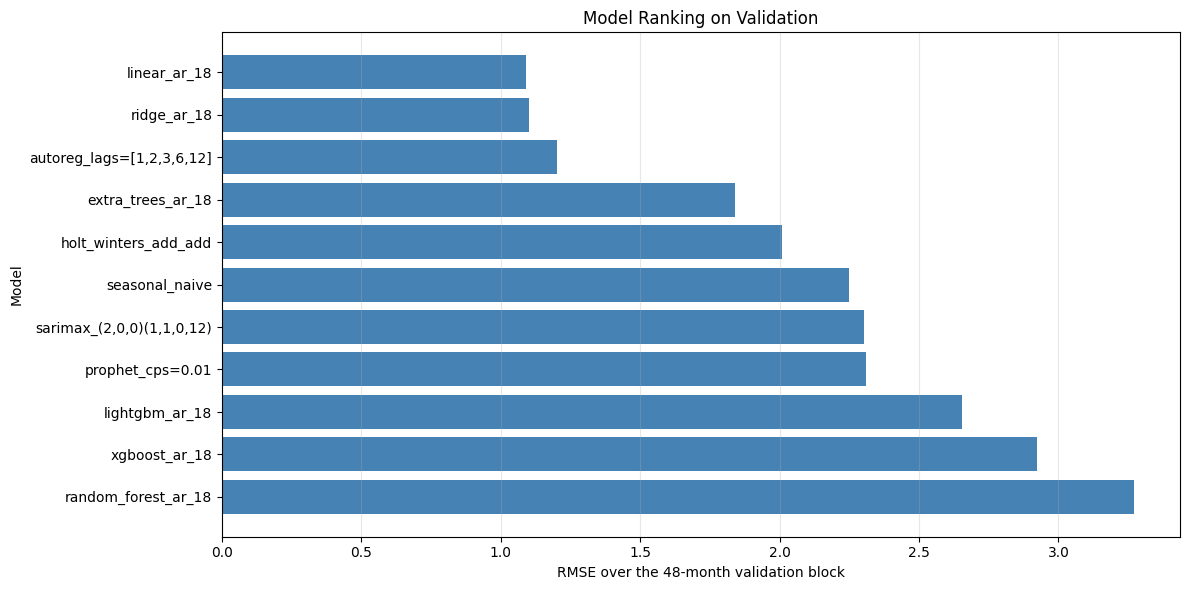

In [11]:
ranked = benchmark_df.sort_values('rmse_48m').reset_index(drop=True)

plt.figure(figsize=(12, 6))
plt.barh(ranked['model'], ranked['rmse_48m'], color='steelblue')
plt.gca().invert_yaxis()
plt.xlabel('RMSE over the 48-month validation block')
plt.ylabel('Model')
plt.title('Model Ranking on Validation')
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()


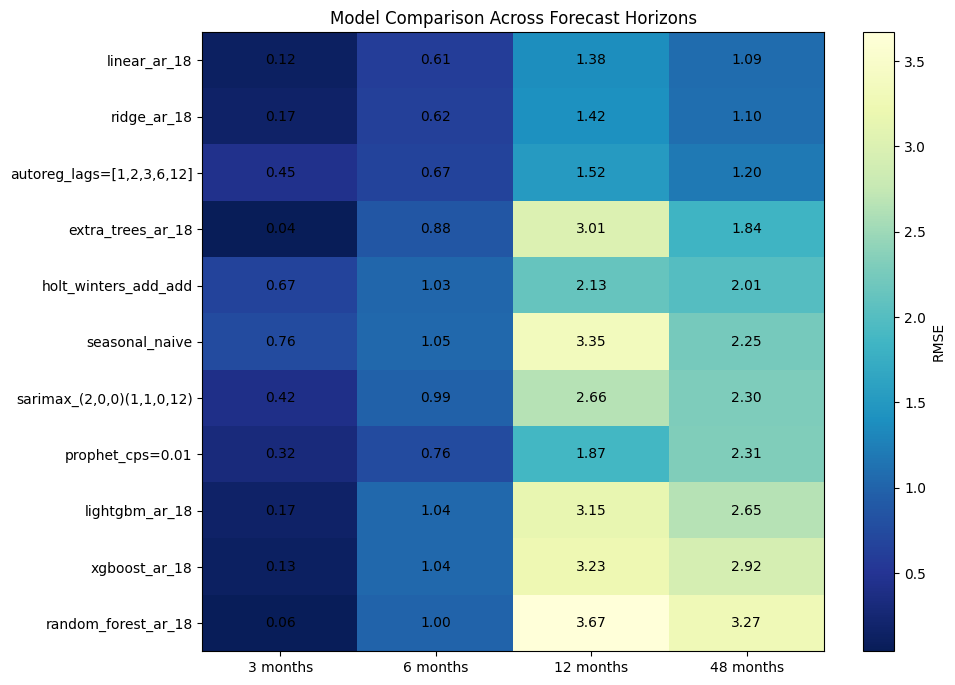

In [12]:
metric_labels = ['3 months', '6 months', '12 months', '48 months']
metric_cols = ['rmse_3m', 'rmse_6m', 'rmse_12m', 'rmse_48m']
heatmap_values = ranked[metric_cols].to_numpy()

plt.figure(figsize=(10, max(5.5, 0.45 * len(ranked) + 2.0)))
image = plt.imshow(heatmap_values, cmap='YlGnBu_r', aspect='auto')
plt.colorbar(image, label='RMSE')
plt.xticks(range(len(metric_labels)), metric_labels)
plt.yticks(range(len(ranked)), ranked['model'])
plt.title('Model Comparison Across Forecast Horizons')

for row in range(heatmap_values.shape[0]):
    for col in range(heatmap_values.shape[1]):
        plt.text(col, row, f'{heatmap_values[row, col]:.2f}', ha='center', va='center', color='black')

plt.tight_layout()
plt.show()


In [13]:
top_n = 6
best_models = ranked.head(top_n)
cols = 2
rows = ceil(len(best_models) / cols)
fig, axes = plt.subplots(rows, cols, figsize=(14, 4.2 * rows), sharex=True, sharey=True)
axes = np.atleast_1d(axes).flatten()

history = train.iloc[-36:]
y_min = min(history.min(), valid.min(), min(np.min(forecast_store[name]) for name in best_models['model']))
y_max = max(history.max(), valid.max(), max(np.max(forecast_store[name]) for name in best_models['model']))
padding = 0.08 * (y_max - y_min)

for ax, (_, row) in zip(axes, best_models.iterrows()):
    model_name = row['model']
    ax.plot(history.index, history.values, color='tab:blue', marker='.', linewidth=1.2, label='Train')
    ax.plot(valid.index, valid.values, color='tab:green', marker='o', linewidth=1.4, label='Truth')
    ax.plot(valid.index, forecast_store[model_name], color='tab:red', linestyle='--', marker='x', linewidth=1.4, label='Forecast')
    ax.set_title(f"{model_name}
48m RMSE = {row['rmse_48m']:.2f}")
    ax.set_ylim(y_min - padding, y_max + padding)
    ax.grid(alpha=0.3)

for ax in axes[len(best_models):]:
    ax.axis('off')

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='upper center', ncol=3, frameon=False)
fig.suptitle('Top Models on the Validation Block', y=0.995)
fig.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()


SyntaxError: unterminated f-string literal (detected at line 18) (2065633024.py, line 18)

## Selected Model

The chosen model is `linear_ar_18` because it gave the best overall recursive RMSE on the 48-month validation block while remaining simple to explain and stable on a small dataset.


In [ ]:
best_name = benchmark_df.iloc[0]['model']
best_pred = forecast_store[best_name]

plt.figure(figsize=(13, 6))
plt.plot(train.index[-60:], train.iloc[-60:], label='Train history', color='tab:blue', marker='.')
plt.plot(valid.index, valid.values, label='Validation truth', color='tab:green', marker='o')
plt.plot(valid.index, best_pred, label=f'Validation forecast ({best_name})', color='tab:red', linestyle='--', marker='x')
plt.title('Best model on the validation block')
plt.xlabel('Date')
plt.ylabel('Groundwater level')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()


In [ ]:
# Retrain the selected model on the full monthly history before forecasting the test period.
full_X, full_y = build_training_data(series)
final_model = LinearRegression()
final_model.fit(full_X, full_y)

test_predictions = recursive_forecast(final_model, series, pd.DatetimeIndex(test_dates))
forecast_df = pd.DataFrame({'date': test_dates, 'target': test_predictions})
forecast_df.to_csv('linear_forecast_test.csv', sep=';', index=False, float_format='%.4f')
benchmark_df.to_csv('benchmark_results.csv', index=False)

forecast_df.head()


## Notes for Presentation

- The preprocessing choice is driven by the assignment: monthly forecasting requires a monthly target series.
- The selected model uses the last 18 months, the month of the year, and rolling summaries to capture seasonality and level.
- More complex models were benchmarked, but they were less stable or worse on the shared validation setup.
